In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target          # median house value in $100k

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.shape
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

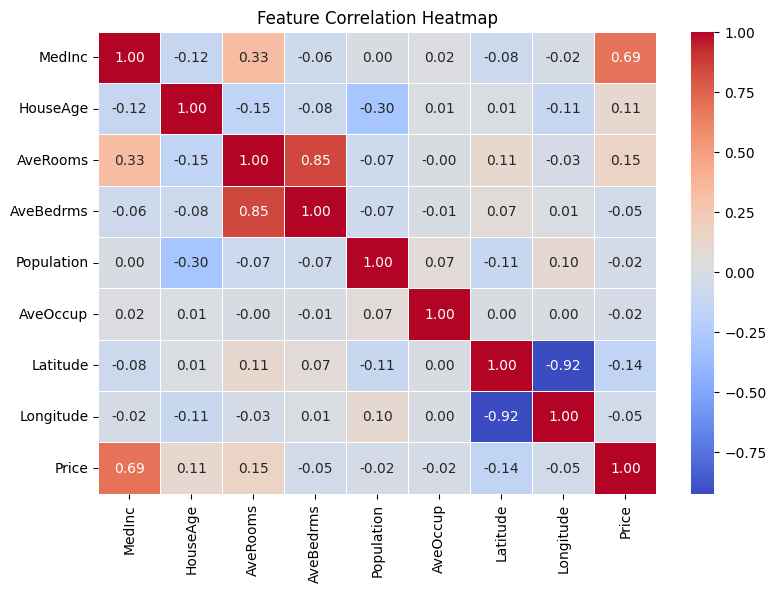

In [9]:
plt.figure(figsize=(9,6))

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(df['Price'], bins=50, kde=True, color='#3498db')

plt.title("House Price Distribution")
plt.xlabel("Price (in $100k)")
plt.ylabel("Count")

plt.show()

# Linear Regression

In [11]:
X_simple = df[['MedInc']].values
y        = df['Price'].values

print("Feature : MedInc (Median Income)")
print("Target  : Price (House Value)")

Feature : MedInc (Median Income)
Target  : Price (House Value)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=0
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

Train : 16512 samples
Test  : 4128 samples


In [13]:
slr_model = LinearRegression()

slr_model.fit(X_train, y_train)

print(f"Coefficient  : {slr_model.coef_[0]:.4f}")
print(f"Intercept    : {slr_model.intercept_:.4f}")
print(f"Equation     : Price = {slr_model.coef_[0]:.4f} * MedInc + {slr_model.intercept_:.4f}")

Coefficient  : 0.4203
Intercept    : 0.4432
Equation     : Price = 0.4203 * MedInc + 0.4432


In [14]:
y_pred_slr = slr_model.predict(X_test)

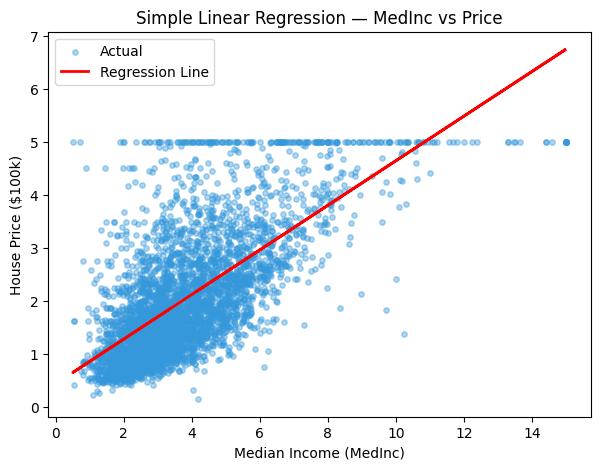

In [15]:
plt.figure(figsize=(7,5))

plt.scatter(X_test, y_test, color='#3498db', alpha=0.4, s=15, label='Actual')
plt.plot(X_test, y_pred_slr, color='red', linewidth=2, label='Regression Line')

plt.title("Simple Linear Regression — MedInc vs Price")
plt.xlabel("Median Income (MedInc)")
plt.ylabel("House Price ($100k)")
plt.legend()

plt.show()

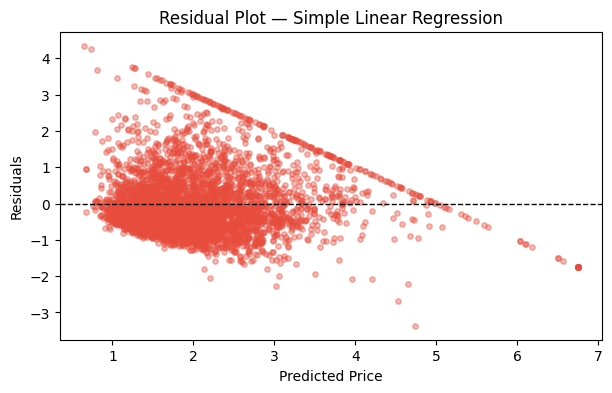

In [16]:
residuals = y_test - y_pred_slr

plt.figure(figsize=(7,4))

plt.scatter(y_pred_slr, residuals, alpha=0.4, color='#e74c3c', s=15)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.title("Residual Plot — Simple Linear Regression")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.show()

In [17]:
mae  = mean_absolute_error(y_test, y_pred_slr)
mse  = mean_squared_error(y_test, y_pred_slr)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_slr)

print("── Simple Linear Regression Metrics ────")
print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

── Simple Linear Regression Metrics ────
  MAE  : 0.6352
  MSE  : 0.7215
  RMSE : 0.8494
  R²   : 0.4467


# Multiple Linear Regression

In [18]:
X_multi = df.drop('Price', axis=1).values
y       = df['Price'].values

print("Features :", df.drop('Price', axis=1).columns.tolist())
print("Target   : Price")

Features : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target   : Price


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=0
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

Train : 16512 samples
Test  : 4128 samples


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [21]:
mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature'     : housing.feature_names,
    'Coefficient' : mlr_model.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))
print(f"\nIntercept : {mlr_model.intercept_:.4f}")

   Feature  Coefficient
    MedInc     0.826248
 AveBedrms     0.290387
  HouseAge     0.117101
Population    -0.008643
  AveOccup    -0.030564
  AveRooms    -0.248911
 Longitude    -0.870586
  Latitude    -0.900421

Intercept : 2.0725


In [22]:
mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature'     : housing.feature_names,
    'Coefficient' : mlr_model.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))
print(f"\nIntercept : {mlr_model.intercept_:.4f}")

   Feature  Coefficient
    MedInc     0.826248
 AveBedrms     0.290387
  HouseAge     0.117101
Population    -0.008643
  AveOccup    -0.030564
  AveRooms    -0.248911
 Longitude    -0.870586
  Latitude    -0.900421

Intercept : 2.0725


In [23]:
y_pred_mlr = mlr_model.predict(X_test)

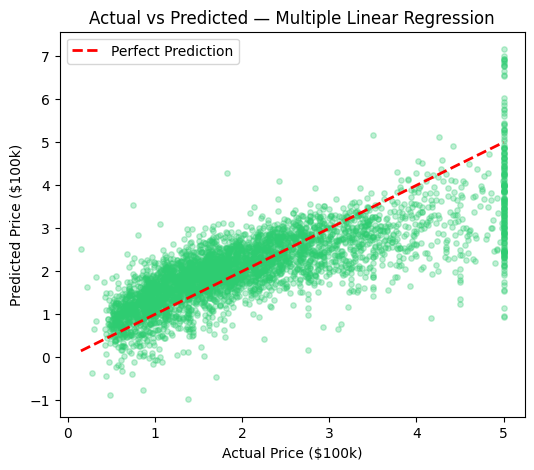

In [24]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_mlr, alpha=0.3, color='#2ecc71', s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')

plt.title("Actual vs Predicted — Multiple Linear Regression")
plt.xlabel("Actual Price ($100k)")
plt.ylabel("Predicted Price ($100k)")
plt.legend()

plt.show()

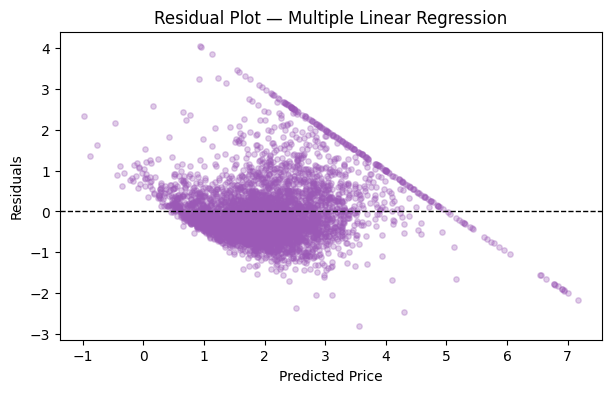

In [25]:
residuals = y_test - y_pred_mlr

plt.figure(figsize=(7,4))

plt.scatter(y_pred_mlr, residuals, alpha=0.3, color='#9b59b6', s=15)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.title("Residual Plot — Multiple Linear Regression")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.show()

In [26]:
mae  = mean_absolute_error(y_test, y_pred_mlr)
mse  = mean_squared_error(y_test, y_pred_mlr)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_mlr)

print("── Multiple Linear Regression Metrics ──")
print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

── Multiple Linear Regression Metrics ──
  MAE  : 0.5351
  MSE  : 0.5290
  RMSE : 0.7273
  R²   : 0.5943


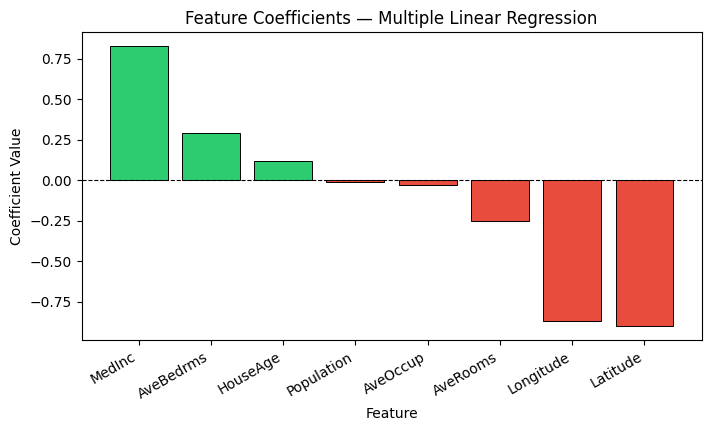

In [27]:
plt.figure(figsize=(8,4))

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.bar(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black', linewidth=0.7)

plt.title("Feature Coefficients — Multiple Linear Regression")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=30, ha='right')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)

plt.show()

In [28]:
comparison = pd.DataFrame({
    "Metric" : ["MAE", "MSE", "RMSE", "R² Score"],
    "Simple LR (MedInc only)" : [
        mean_absolute_error(y_test, slr_model.predict(scaler.transform(X_test[:, :1])) if False else slr_model.predict(
            df[['MedInc']].iloc[-len(y_test):].values)),
        mean_squared_error(y_test, slr_model.predict(
            df[['MedInc']].iloc[-len(y_test):].values)),
        np.sqrt(mean_squared_error(y_test, slr_model.predict(
            df[['MedInc']].iloc[-len(y_test):].values))),
        r2_score(y_test, slr_model.predict(
            df[['MedInc']].iloc[-len(y_test):].values))
    ],
    "Multiple LR (all features)" : [
        mean_absolute_error(y_test, y_pred_mlr),
        mean_squared_error(y_test, y_pred_mlr),
        np.sqrt(mean_squared_error(y_test, y_pred_mlr)),
        r2_score(y_test, y_pred_mlr)
    ]
}).set_index("Metric")

print(comparison.round(4).to_string())

          Simple LR (MedInc only)  Multiple LR (all features)
Metric                                                       
MAE                        1.0971                      0.5351
MSE                        1.9889                      0.5290
RMSE                       1.4103                      0.7273
R² Score                  -0.5253                      0.5943


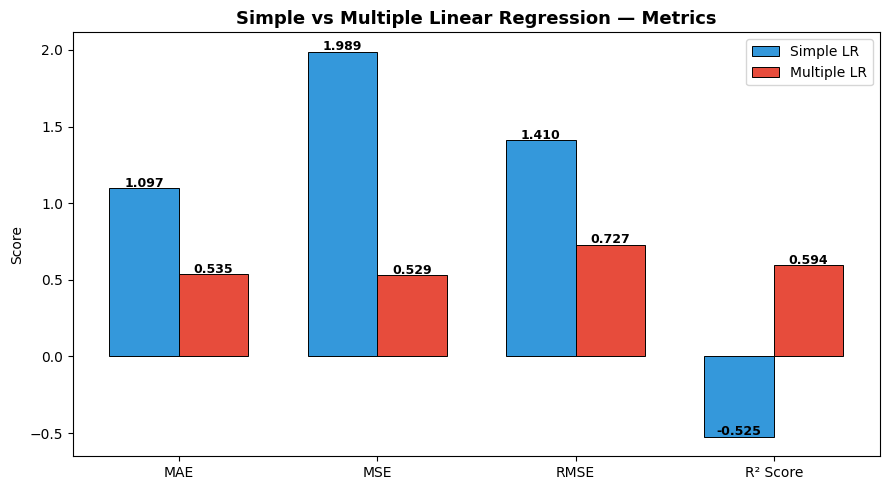

In [30]:
metrics = ["MAE", "MSE", "RMSE", "R² Score"]
x       = np.arange(len(metrics))
width   = 0.35

slr_vals = comparison["Simple LR (MedInc only)"].values
mlr_vals = comparison["Multiple LR (all features)"].values

fig, ax = plt.subplots(figsize=(9,5))

bars1 = ax.bar(x - width/2, slr_vals, width, label='Simple LR',   color='#3498db', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, mlr_vals, width, label='Multiple LR', color='#e74c3c', edgecolor='black', linewidth=0.7)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title("Simple vs Multiple Linear Regression — Metrics", fontsize=13, fontweight='bold')
ax.set_ylabel("Score")
ax.legend()

plt.tight_layout()
plt.show()